<a href="https://colab.research.google.com/github/HafizRizqi/PCVK_2026/blob/main/week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


-----------------------------------
 Mengubah tingkat kecerahan citra 
-----------------------------------
Masukkan nilai kecerahan: 5


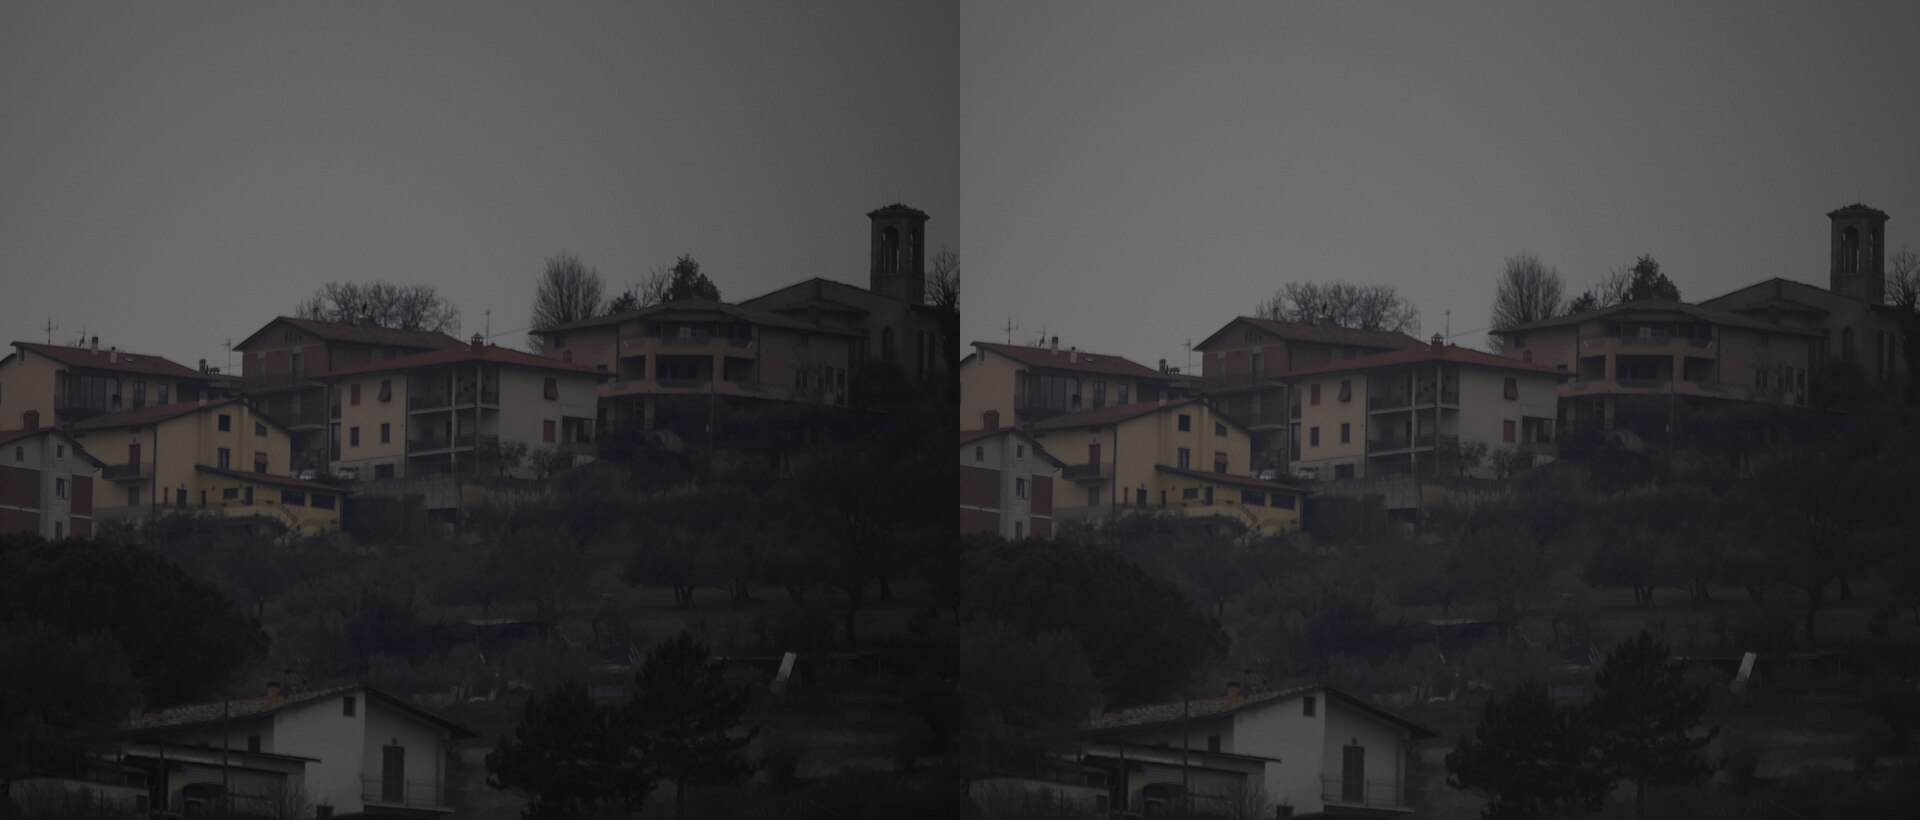

In [3]:
# formula g(x,y) = f(x,y) + b
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print('-----------------------------------')
print(' Mengubah tingkat kecerahan citra ')
print('-----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

# sesuaikan dengan file dan folder di drive Anda
original = cv.imread('/content/drive/MyDrive/Kuliah//houses.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

# akses per piksel
# np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y, x, c] = np.clip(original[y, x, c] + brightness, 0, 255)

# cara simple tanpa for loop
# brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat([original, brightness_image])
cv2_imshow(final_frame)


In [9]:
import matplotlib.pyplot as plt
import math
import glob
import os

1. Inversi Citra
inverse menggunakan rumus:

$$ g(x,y)=255-f(x,y) $$

Artinya setiap nilai pixel dikurangi dari 255 sehingga citra menjadi negatif.

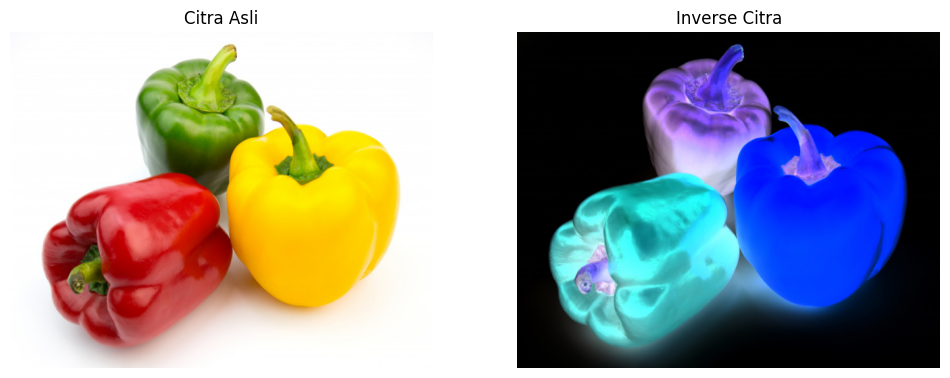

In [10]:
# Path gambar template
image_path = '/content/drive/MyDrive/Kuliah/peppers.jpg'

# Membaca gambar
original = cv.imread(image_path)

# Konversi BGR ke RGB untuk ditampilkan
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# Inverse citra
inverse = 255 - original

# Konversi hasil ke RGB
inverse_rgb = cv.cvtColor(inverse, cv.COLOR_BGR2RGB)

# Menampilkan gambar
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(inverse_rgb)
plt.title('Inverse Citra')
plt.axis('off')

plt.show()

2. Transformasi Contrast
rumus:

$$ F=\frac{259(C+255)}{255(259-C)} $$

kemudian:

$$ R'=F(R-128)+128 $$

Rumus yang sama diterapkan pada channel Green dan Blue. Nilai hasil kemudian harus dibatasi pada rentang 0–255.

Mengubah kontras dan tingkat kecerahan citra
----------------------------------------------
Masukkan tingkat kecerahan : 10
Masukkan kontras : 1.5


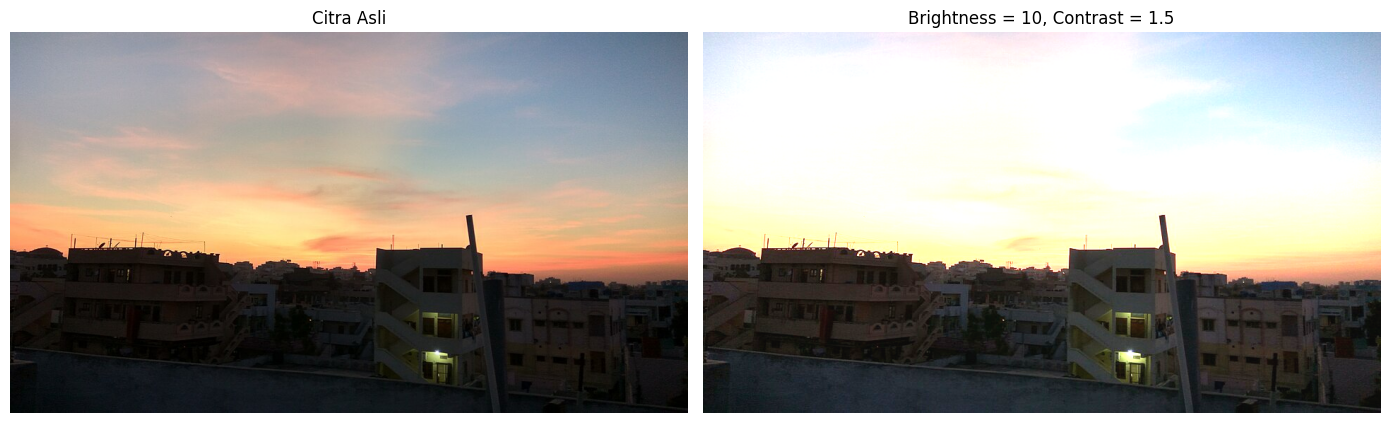

In [13]:
print("Mengubah kontras dan tingkat kecerahan citra")
print("----------------------------------------------")

# Input tingkat kecerahan
brightness = int(input("Masukkan tingkat kecerahan : "))

# Input nilai kontras
contrast = float(input("Masukkan kontras : "))

# Membaca gambar
image_path = '/content/drive/MyDrive/Kuliah/sunset.jpg'
original = cv.imread(image_path)

# Mengubah tipe data agar perhitungan dapat dilakukan
image = original.astype(np.float32)

# Transformasi contrast dan brightness
result = contrast * image + brightness

# Truncate agar nilai pixel tetap berada pada range 0-255
result = np.clip(result, 0, 255)

# Mengubah kembali ke uint8
result = result.astype(np.uint8)

# Konversi BGR ke RGB untuk matplotlib
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
result_rgb = cv.cvtColor(result, cv.COLOR_BGR2RGB)

# Menampilkan citra
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title("Citra Asli")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_rgb)
plt.title(f"Brightness = {brightness}, Contrast = {contrast}")
plt.axis("off")

plt.tight_layout()
plt.show()

3. Transformasi Logarithmic Brightness
Rumus dari modul:

$$ s=c\log(1+r) $$

dengan r sebagai nilai gray-level input dan s sebagai output.

Mengubah tingkat kecerahan citra dengan Transformasi Log
---------------------------------------------------------
Masukkan nilai kecerahan: 50


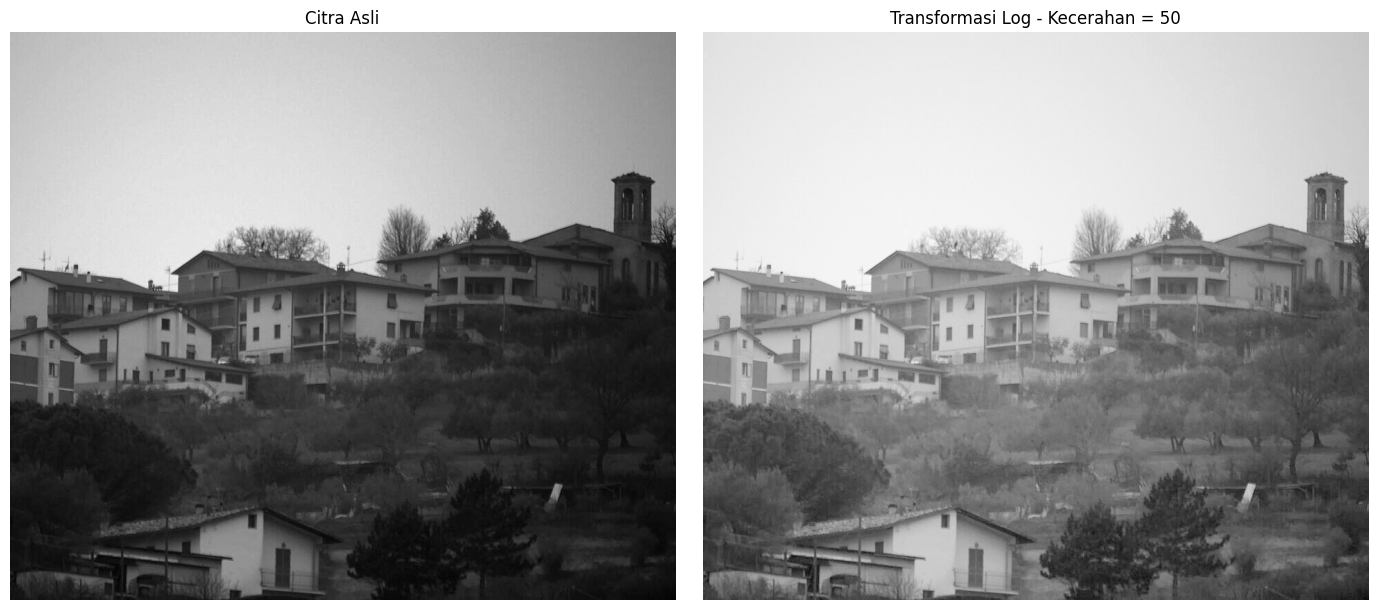

In [14]:
print("Mengubah tingkat kecerahan citra dengan Transformasi Log")
print("---------------------------------------------------------")

# Input nilai kecerahan
brightness = int(input("Masukkan nilai kecerahan: "))

# Membaca gambar
image_path = '/content/drive/MyDrive/Kuliah/houses.jpg'
original = cv.imread(image_path)

# Mengubah gambar ke grayscale
gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)

# Konstanta transformasi log
c = brightness

# Transformasi logarithmic
log_image = c * np.log(1 + gray.astype(np.float32))

# Normalisasi hasil agar berada pada range 0-255
log_image = cv.normalize(
    log_image,
    None,
    0,
    255,
    cv.NORM_MINMAX
)

# Mengubah menjadi uint8
log_image = log_image.astype(np.uint8)

# Menampilkan hasil
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title("Citra Asli")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(log_image, cmap='gray')
plt.title(f"Transformasi Log - Kecerahan = {brightness}")
plt.axis("off")

plt.tight_layout()
plt.show()

4. Grayscale
tiga metode:

Averaging
Lightness
Luminance

Rumusnya adalah:

Averaging
$$ Gray=\frac{R+G+B}{3} $$
Lightness
$$ Gray=\frac{max(R,G,B)+min(R,G,B)}{2} $$
Luminance
$$ Gray=0.21R+0.72G+0.07B $$

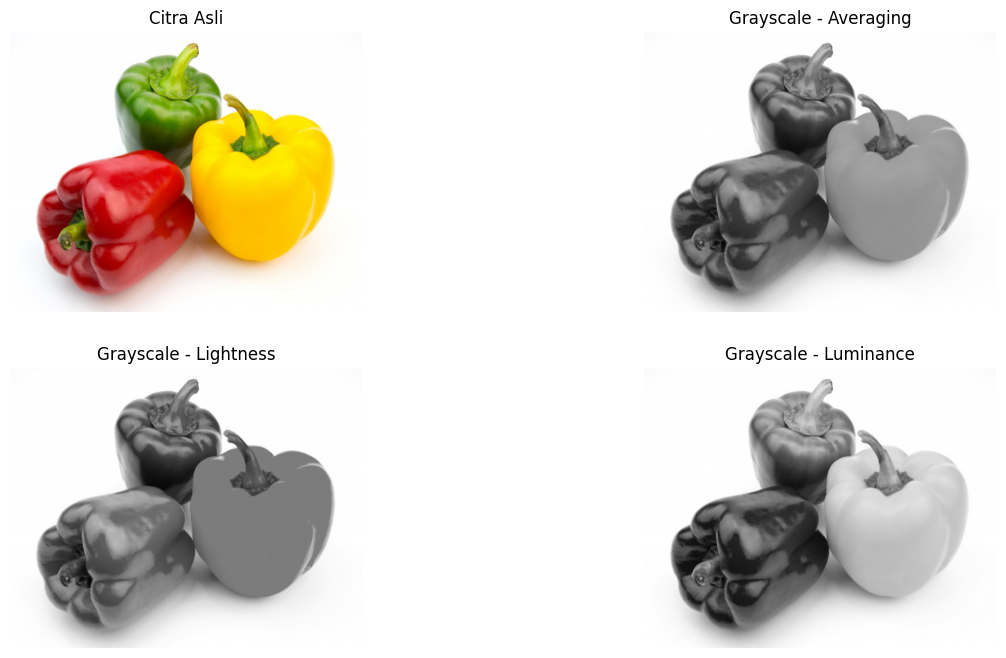

In [15]:
image_path = '/content/drive/MyDrive/Kuliah/peppers.jpg'

original = cv.imread(image_path)

# OpenCV membaca BGR
B, G, R = cv.split(original)

# Mengubah ke float
R = R.astype(np.float32)
G = G.astype(np.float32)
B = B.astype(np.float32)

# 1. Averaging
gray_averaging = (R + G + B) / 3
gray_averaging = np.clip(gray_averaging, 0, 255).astype(np.uint8)

# 2. Lightness
gray_lightness = (np.maximum(np.maximum(R, G), B) +
                  np.minimum(np.minimum(R, G), B)) / 2
gray_lightness = np.clip(gray_lightness, 0, 255).astype(np.uint8)

# 3. Luminance
gray_luminance = 0.21 * R + 0.72 * G + 0.07 * B
gray_luminance = np.clip(gray_luminance, 0, 255).astype(np.uint8)

# Menampilkan hasil
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(gray_averaging, cmap='gray')
plt.title('Grayscale - Averaging')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(gray_lightness, cmap='gray')
plt.title('Grayscale - Lightness')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(gray_luminance, cmap='gray')
plt.title('Grayscale - Luminance')
plt.axis('off')

plt.show()

5. Menampilkan Warna Merah dan Mengubah Warna Lain Menjadi Grayscale

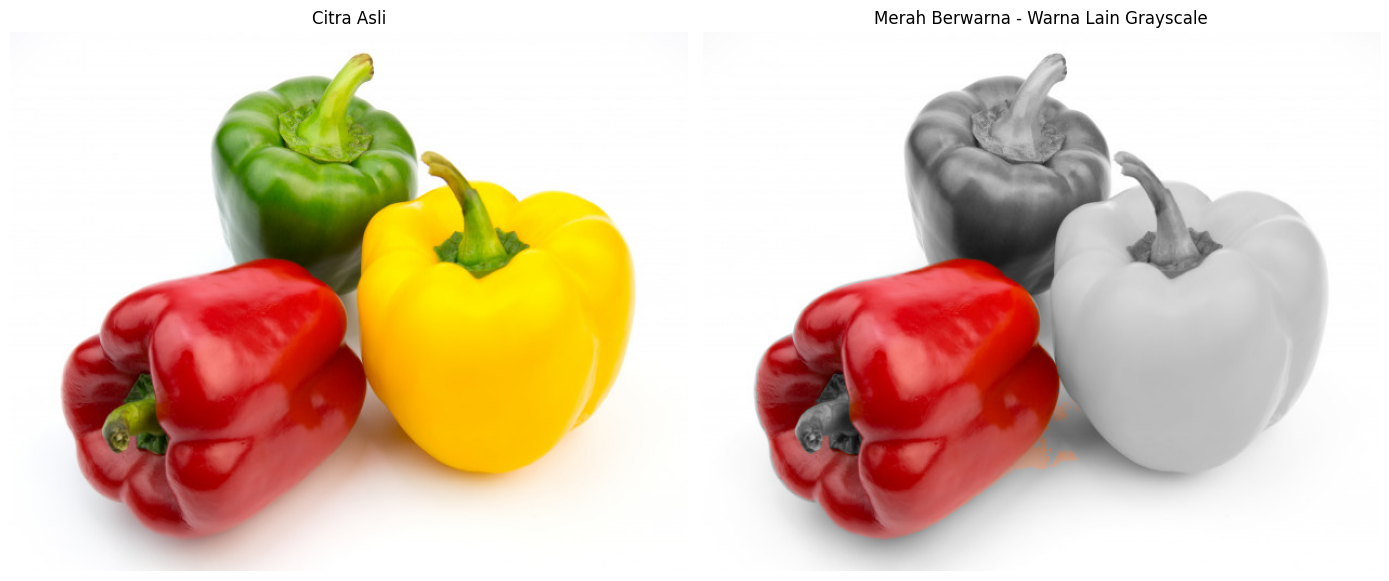

In [21]:
image_path = '/content/drive/MyDrive/Kuliah/peppers.jpg'

original = cv.imread(image_path)

# Konversi BGR ke RGB untuk ditampilkan
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# Konversi BGR ke HSV
hsv = cv.cvtColor(original, cv.COLOR_BGR2HSV)

# Membuat mask untuk warna merah
# Merah berada pada bagian awal dan akhir rentang Hue
lower_red1 = np.array([0, 80, 50])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 80, 50])
upper_red2 = np.array([179, 255, 255])

mask1 = cv.inRange(hsv, lower_red1, upper_red1)
mask2 = cv.inRange(hsv, lower_red2, upper_red2)

# Menggabungkan kedua mask merah
red_mask = cv.bitwise_or(mask1, mask2)

# Mengubah seluruh citra menjadi grayscale
gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)

# Mengubah grayscale menjadi 3 channel
gray_rgb = cv.cvtColor(gray, cv.COLOR_GRAY2RGB)

# Membuat hasil awal berupa grayscale
result = gray_rgb.copy()

# Mempertahankan warna asli pada bagian yang berwarna merah
result[red_mask > 0] = original_rgb[red_mask > 0]

# Menampilkan hasil
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result)
plt.title('Merah Berwarna - Warna Lain Grayscale')
plt.axis('off')

plt.tight_layout()
plt.show()

6. Gamma Correction
rumus:

$$ I'=255\left(\frac{I}{255}\right)^{1/\gamma} $$

dan meminta nilai gamma dimasukkan oleh pengguna.

Gamma Correction pada citra
----------------------------------
Masukkan nilai gamma: 0.5


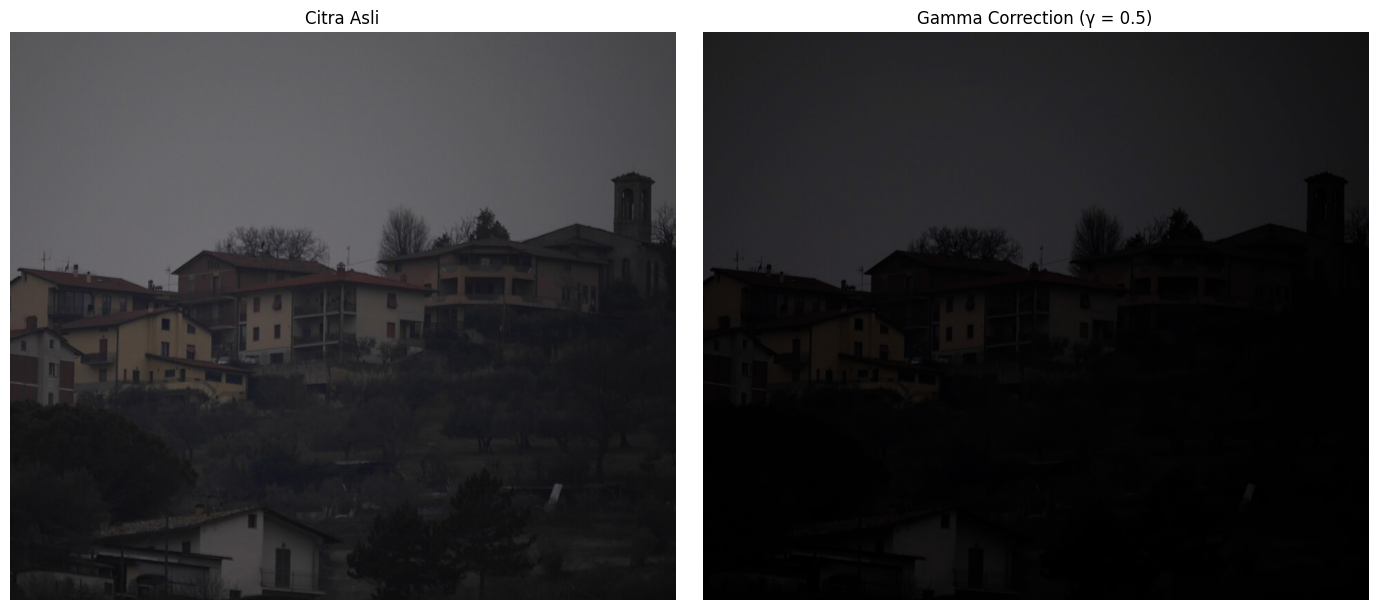

In [27]:
print("Gamma Correction pada citra")
print("----------------------------------")

# Meminta input nilai gamma
try:
    gamma = float(input("Masukkan nilai gamma: "))

    if gamma <= 0:
        print("Nilai gamma harus lebih besar dari 0")
    else:
        # Path gambar template
        image_path = '/content/drive/MyDrive/Kuliah/houses.jpg'

        # Membaca citra
        original = cv.imread(image_path)

        # Konversi BGR ke RGB
        original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

        # Gamma Correction
        gamma_correction = 255 * (
            (original / 255) ** (1 / gamma)
        )

        # Memastikan nilai pixel berada pada range 0-255
        gamma_correction = np.clip(
            gamma_correction, 0, 255
        ).astype(np.uint8)

        # Konversi hasil ke RGB
        gamma_rgb = cv.cvtColor(
            gamma_correction,
            cv.COLOR_BGR2RGB
        )

        # Menampilkan hasil
        plt.figure(figsize=(14, 6))

        plt.subplot(1, 2, 1)
        plt.imshow(original_rgb)
        plt.title("Citra Asli")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(gamma_rgb)
        plt.title(f"Gamma Correction (γ = {gamma})")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

except ValueError:
    print("Error, not a number")

7. Simulasi Image Depth


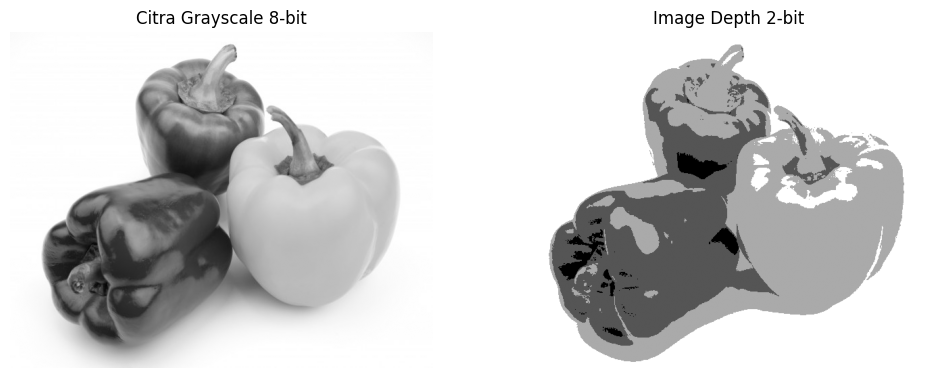

In [29]:
bit_depth = 2

image_path = '/content/drive/MyDrive/Kuliah/peppers.jpg'

# Membaca citra grayscale
original = cv.imread(image_path, cv.IMREAD_GRAYSCALE)

# Menghitung level
level = 255 / (pow(2, bit_depth) - 1)

# Membuat citra kosong
depth_image = np.zeros(original.shape, original.dtype)

# Proses kuantisasi
for i in range(original.shape[0]):
    for j in range(original.shape[1]):
        depth_image[i, j] = round(
            (original[i, j] / level)
        ) * level

# Membatasi nilai 0-255
depth_image = np.clip(depth_image, 0, 255).astype(np.uint8)

# Menampilkan
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original, cmap='gray')
plt.title('Citra Grayscale 8-bit')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(depth_image, cmap='gray')
plt.title(f'Image Depth {bit_depth}-bit')
plt.axis('off')

plt.show()

8. Average Denoising

In [30]:
# Membaca citra asli
original_path = '/content/drive/MyDrive/Kuliah/galaxy.jpg'
original = cv.imread(original_path)

# Membaca seluruh gambar noise
cv_img = []

for img_path in glob.glob(
    '/content/drive/MyDrive/Kuliah/noises/*.jpg'
):
    n = cv.imread(img_path)
    cv_img.append(n)

print("Jumlah gambar noise:", len(cv_img))

Jumlah gambar noise: 100


In [31]:
def average_denoising(images):
    images_float = np.array(images, dtype=np.float32)

    average = np.mean(images_float, axis=0)

    return np.clip(average, 0, 255).astype(np.uint8)

In [32]:
def PSNR(img1, img2):
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)

    mse = np.mean((img1 - img2) ** 2)

    if mse == 0:
        return 100

    max_pixel = 255.0

    psnr = 20 * math.log10(max_pixel / math.sqrt(mse))

    return psnr

Menghitung 10, 20, 40, 80, 100 gambar

In [33]:
jumlah_citra = [10, 20, 40, 80, 100]

hasil_psnr = []

for jumlah in jumlah_citra:

    # Mengambil sejumlah gambar
    selected_images = cv_img[:jumlah]

    # Average denoising
    denoised = average_denoising(selected_images)

    # Menghitung PSNR
    psnr_value = PSNR(original, denoised)

    hasil_psnr.append(psnr_value)

    print(f"Jumlah citra: {jumlah}")
    print(f"PSNR: {psnr_value:.2f} dB")
    print("----------------------------------")

Jumlah citra: 10
PSNR: 19.74 dB
----------------------------------
Jumlah citra: 20
PSNR: 19.84 dB
----------------------------------
Jumlah citra: 40
PSNR: 19.89 dB
----------------------------------
Jumlah citra: 80
PSNR: 19.92 dB
----------------------------------
Jumlah citra: 100
PSNR: 19.92 dB
----------------------------------


Membuat hasil tabel

In [34]:
import pandas as pd

hasil = pd.DataFrame({
    'Jumlah Citra di Average': jumlah_citra,
    'Nilai PSNR (dB)': hasil_psnr
})

hasil

,Jumlah Citra di Average,Nilai PSNR (dB)
0,10,19.735083
1,20,19.837056
2,40,19.887144
3,80,19.916456
4,100,19.921961


Menampilkan hasil Gambar

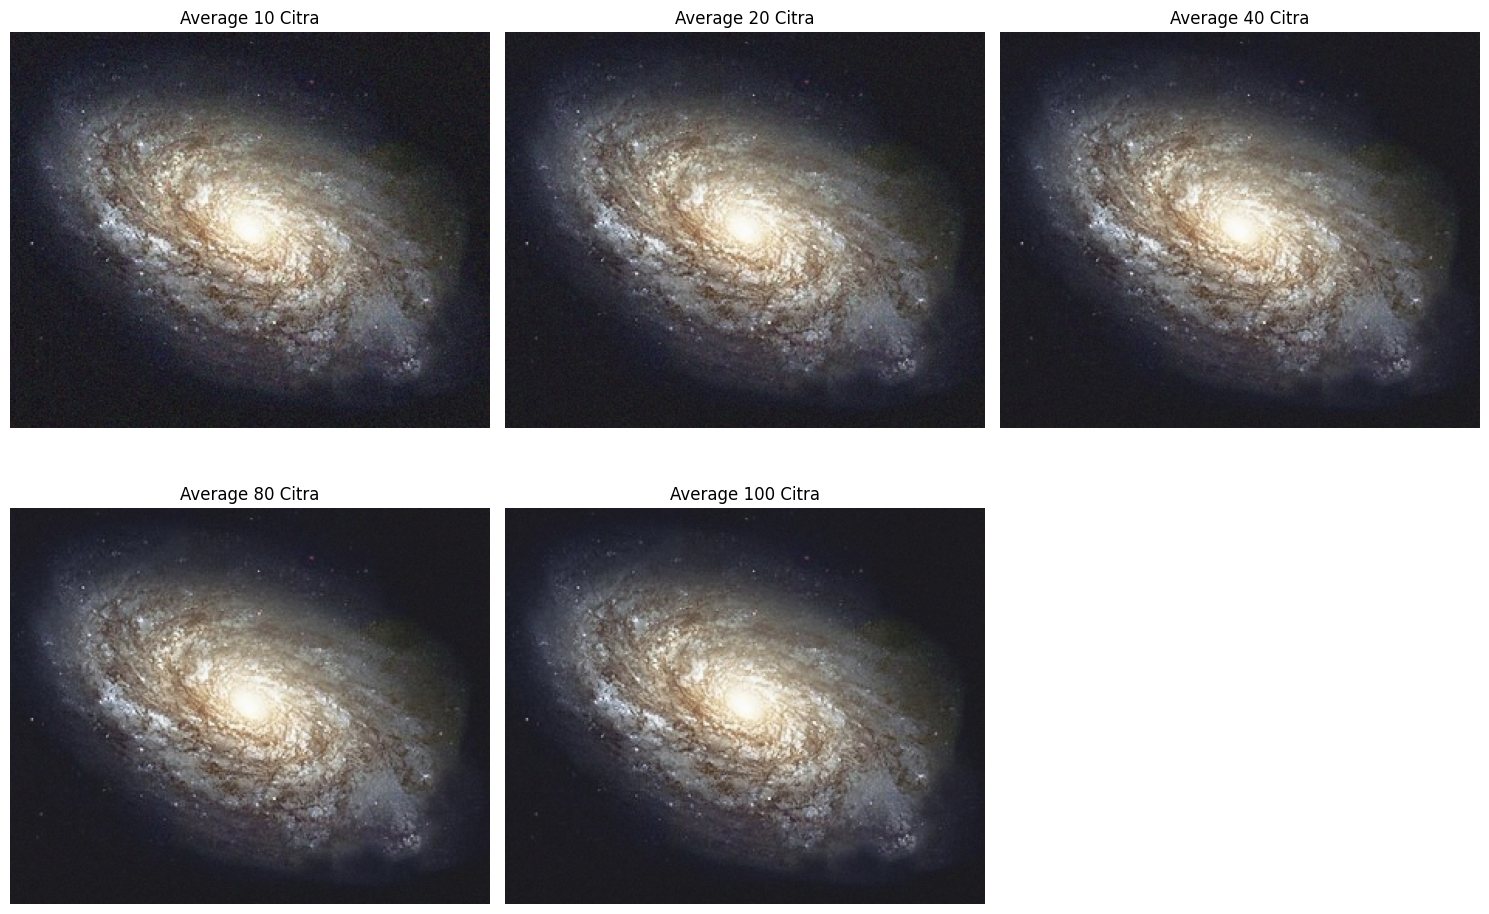

In [35]:
plt.figure(figsize=(15, 10))

for i, jumlah in enumerate(jumlah_citra):

    denoised = average_denoising(cv_img[:jumlah])

    plt.subplot(2, 3, i + 1)
    plt.imshow(cv.cvtColor(denoised, cv.COLOR_BGR2RGB))
    plt.title(f'Average {jumlah} Citra')
    plt.axis('off')

plt.tight_layout()
plt.show()

9. Image Masking

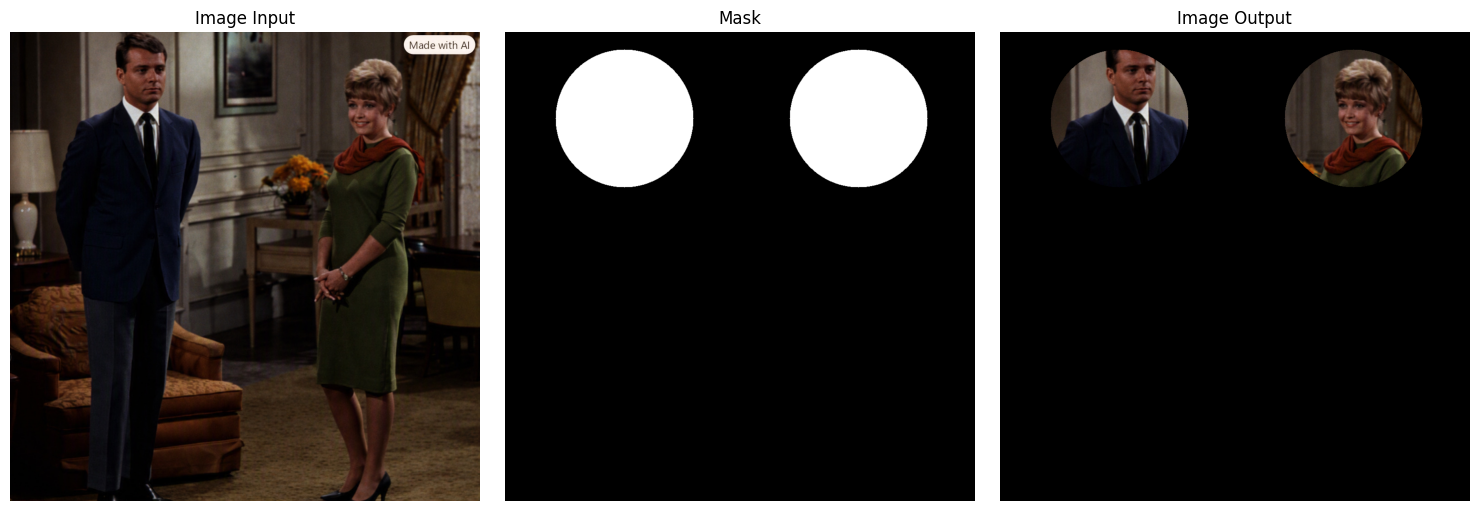

In [44]:
image_path = '/content/drive/MyDrive/Kuliah/couple2.jpg'

original = cv.imread(image_path)

# Konversi BGR ke RGB
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# Mendapatkan ukuran gambar
height, width = original.shape[:2]

# Membuat mask
# Mask awal berwarna hitam
mask = np.zeros((height, width), dtype=np.uint8)

# SESUAIKAN koordinat dengan gambar kamu
# cv.circle(mask, (x, y), radius, warna, ketebalan)

# Lingkaran orang pertama
cv.circle(mask, (260, 190), 150, 255, -1)

# Lingkaran orang kedua
cv.circle(mask, (770, 190), 150, 255, -1)

# Image Masking menggunakan AND
result = cv.bitwise_and(original, original, mask=mask)

# Konversi hasil ke RGB
result_rgb = cv.cvtColor(result, cv.COLOR_BGR2RGB)
# Menampilkan hasil
plt.figure(figsize=(15, 5))

# Citra asli
plt.subplot(1, 3, 1)
plt.imshow(original_rgb)
plt.title("Image Input")
plt.axis("off")

# Mask
plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title("Mask")
plt.axis("off")

# Hasil masking
plt.subplot(1, 3, 3)
plt.imshow(result_rgb)
plt.title("Image Output")
plt.axis("off")

plt.tight_layout()
plt.show()

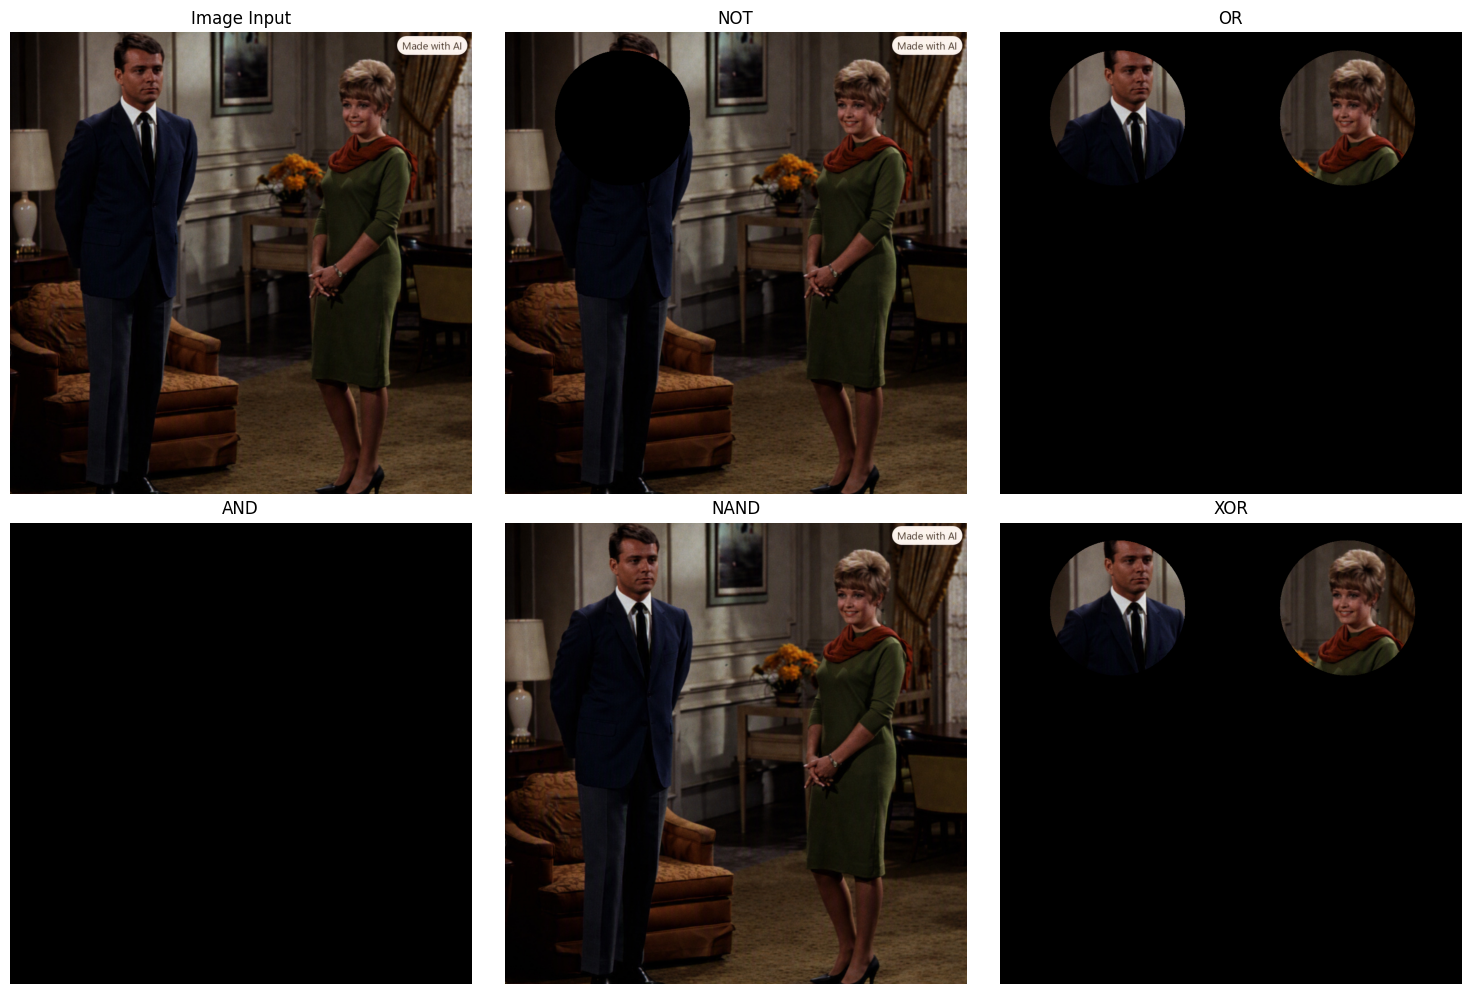

In [45]:
image_path = '/content/drive/MyDrive/Kuliah/couple2.jpg'

original = cv.imread(image_path)

# Konversi BGR ke RGB
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# Ukuran gambar
height, width = original.shape[:2]


# ==========================================
# Membuat dua mask
# ==========================================

# Mask 1 = orang sebelah kiri
mask1 = np.zeros((height, width), dtype=np.uint8)
cv.circle(mask1, (260, 190), 150, 255, -1)

# Mask 2 = orang sebelah kanan
mask2 = np.zeros((height, width), dtype=np.uint8)
cv.circle(mask2, (770, 190), 150, 255, -1)


# ==========================================
# 1. NOT
# ==========================================

not_mask = cv.bitwise_not(mask1)

not_result = cv.bitwise_and(
    original,
    original,
    mask=not_mask
)


# ==========================================
# 2. OR
# ==========================================

or_mask = cv.bitwise_or(mask1, mask2)

or_result = cv.bitwise_and(
    original,
    original,
    mask=or_mask
)


# ==========================================
# 3. AND
# ==========================================

and_mask = cv.bitwise_and(mask1, mask2)

and_result = cv.bitwise_and(
    original,
    original,
    mask=and_mask
)


# ==========================================
# 4. NAND
# ==========================================

nand_mask = cv.bitwise_not(
    cv.bitwise_and(mask1, mask2)
)

nand_result = cv.bitwise_and(
    original,
    original,
    mask=nand_mask
)


# ==========================================
# 5. XOR
# ==========================================

xor_mask = cv.bitwise_xor(mask1, mask2)

xor_result = cv.bitwise_and(
    original,
    original,
    mask=xor_mask
)


# ==========================================
# Konversi hasil BGR ke RGB
# ==========================================

not_result = cv.cvtColor(not_result, cv.COLOR_BGR2RGB)
or_result = cv.cvtColor(or_result, cv.COLOR_BGR2RGB)
and_result = cv.cvtColor(and_result, cv.COLOR_BGR2RGB)
nand_result = cv.cvtColor(nand_result, cv.COLOR_BGR2RGB)
xor_result = cv.cvtColor(xor_result, cv.COLOR_BGR2RGB)


# ==========================================
# Menampilkan hasil
# ==========================================

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(original_rgb)
plt.title("Image Input")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(not_result)
plt.title("NOT")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(or_result)
plt.title("OR")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(and_result)
plt.title("AND")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(nand_result)
plt.title("NAND")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(xor_result)
plt.title("XOR")
plt.axis("off")

plt.tight_layout()
plt.show()

10. Foto Malam Hari

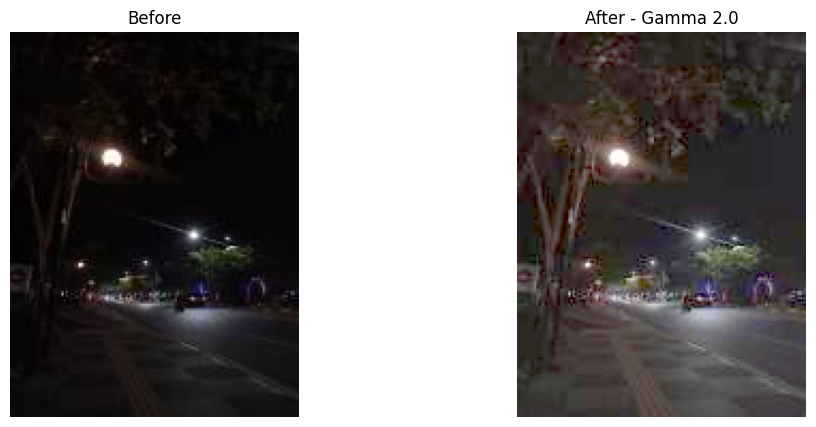

In [46]:
# menggunakan gamma correction
image_path = '/content/drive/MyDrive/Kuliah/malam.jpg'

original = cv.imread(image_path)

gamma = 2.0

gamma_image = 255 * ((original / 255) ** (1 / gamma))

gamma_image = np.clip(gamma_image, 0, 255).astype(np.uint8)

# Konversi BGR ke RGB
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
gamma_rgb = cv.cvtColor(gamma_image, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title('Before')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gamma_rgb)
plt.title(f'After - Gamma {gamma}')
plt.axis('off')

plt.show()

11. Memperbaiki Kualitas crayfish.jpg

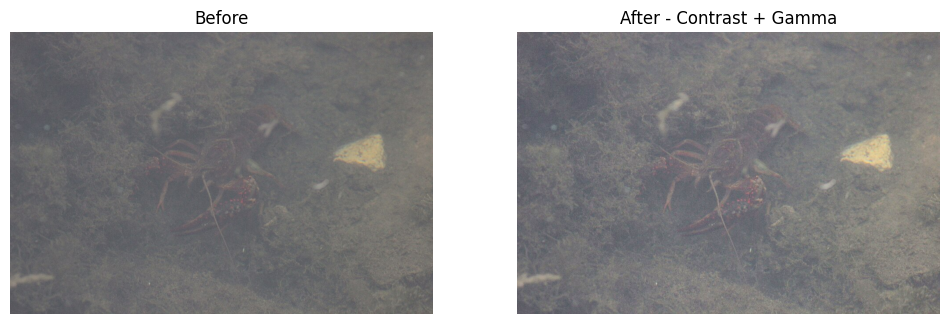

In [47]:
image_path = '/content/drive/MyDrive/Kuliah/crayfish.jpg'

original = cv.imread(image_path)
# 1. Contrast

contrast = 50

factor = (259 * (contrast + 255)) / (255 * (259 - contrast))

contrast_image = original.astype(np.float32)

contrast_image = factor * (contrast_image - 128) + 128

contrast_image = np.clip(contrast_image, 0, 255).astype(np.uint8)

# 2. Gamma Correction

gamma = 1.3

enhanced = 255 * ((contrast_image / 255) ** (1 / gamma))

enhanced = np.clip(enhanced, 0, 255).astype(np.uint8)

# Menampilkan Before-After

original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
enhanced_rgb = cv.cvtColor(enhanced, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title('Before')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(enhanced_rgb)
plt.title('After - Contrast + Gamma')
plt.axis('off')

plt.show()